# Here lies a Scientific-Oriented Data Analysis of an Insurance Dataset

### 1. We Import all Dependencies Needed

In [14]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

### 2. We Extract the Data from a CSV File

In [15]:
URL_PATH = os.getcwd() + "\\Datasets_option1\\insurance.csv"

insurance_df = pd.read_csv(URL_PATH)

insurance_df.head(1)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9,0,yes,southwest,16884.924


### 3. Let's Analyze the Dataset

In [10]:
insurance_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In terms of data types, everything seems ok.

In [11]:
insurance_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [17]:
insurance_df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In terms of rows count, everything seems ok too.

### 4. The Dataset is Ready. It's time to define variable types

In [20]:
target = "charges"

categorical_features = ["sex", "smoker", "region"]
numerical_features = ["age", "bmi", "children"]

X = insurance_df.drop(columns=target)
y = insurance_df[target]

### 5. Descriptive Analysis - What happened?

#### 5.1 Distribution of charges

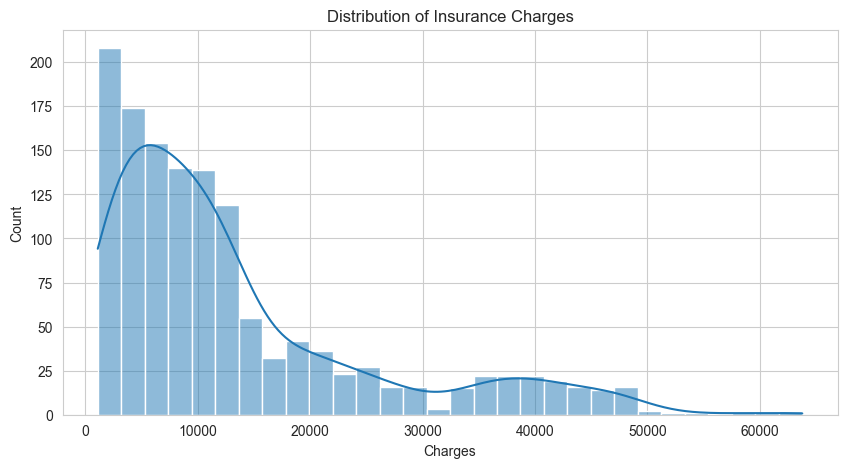

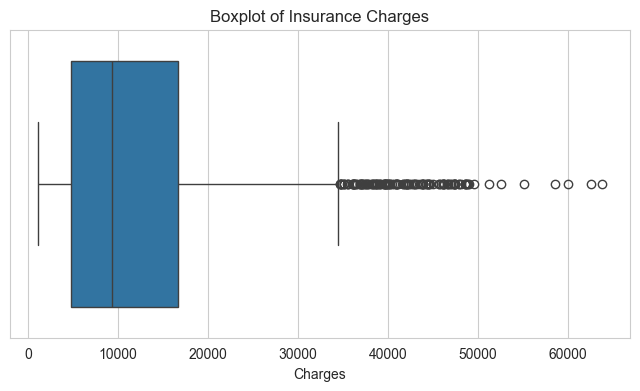

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(insurance_df["charges"], bins=30, kde=True)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=insurance_df["charges"])
plt.title("Boxplot of Insurance Charges")
plt.xlabel("Charges")
plt.show()

#### 5.2 Distribution of numerical variables

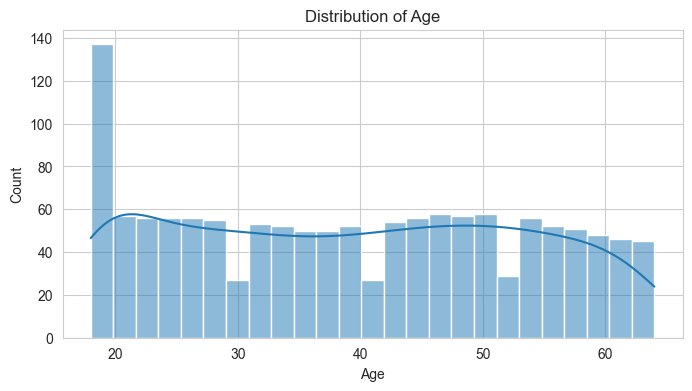

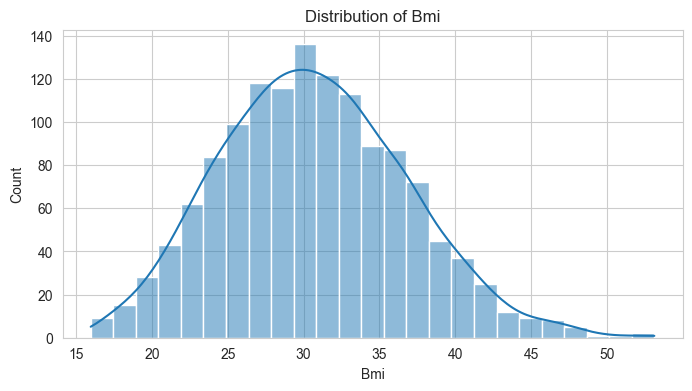

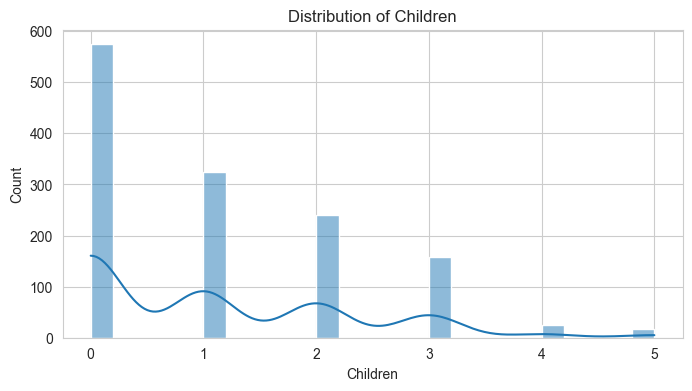

In [25]:
for col in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(insurance_df[col], bins=25, kde=True)
    plt.title(f"Distribution of {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Count")
    plt.show()

#### 5.3 Categorical breakdown

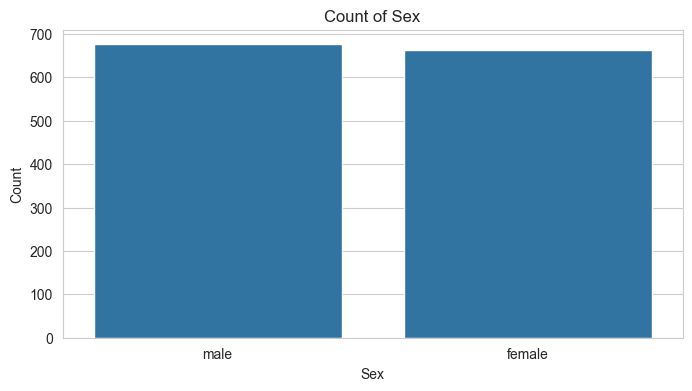

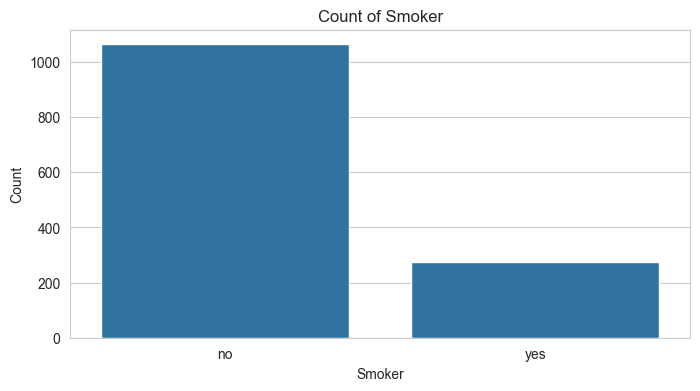

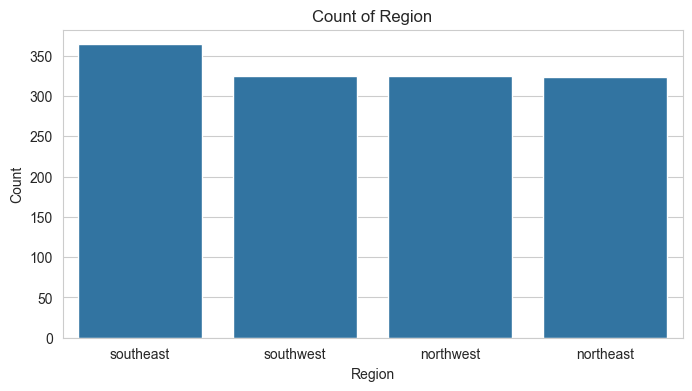

In [27]:
for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=insurance_df, x=col, order=insurance_df[col].value_counts().index)
    plt.title(f"Count of {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Count")
    plt.show()

#### 5.4 Average charges by category

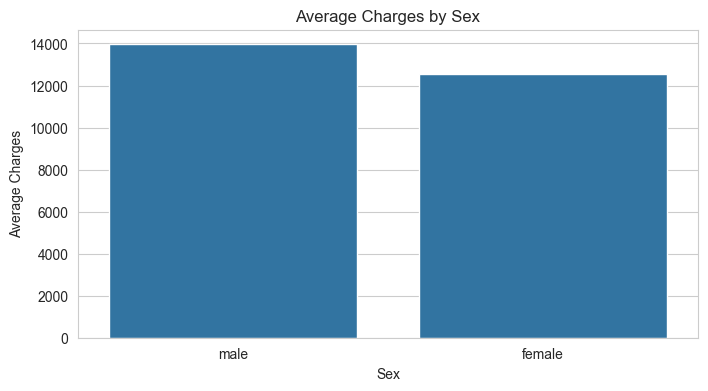

,avg_charges
sex,
male,13956.751178
female,12569.578844


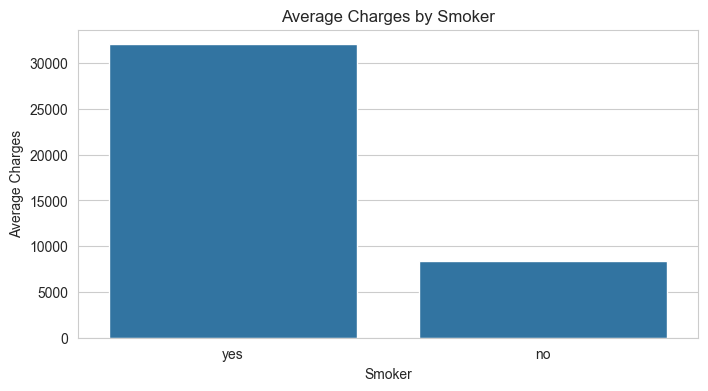

,avg_charges
smoker,
yes,32050.231832
no,8434.268298


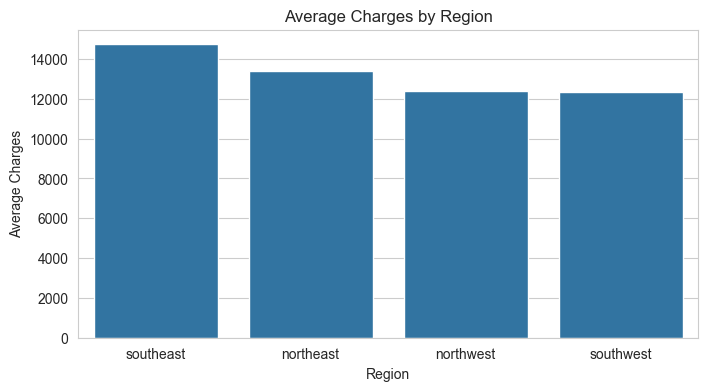

,avg_charges
region,
southeast,14735.411438
northeast,13406.384516
northwest,12417.575374
southwest,12346.937377


In [29]:
for col in categorical_features:
    avg_charge = insurance_df.groupby(col)["charges"].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=avg_charge.index, y=avg_charge.values)
    plt.title(f"Average Charges by {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Average Charges")
    plt.show()
    
    display(avg_charge.to_frame(name="avg_charges"))

#### 5.5 Charges by smoker status

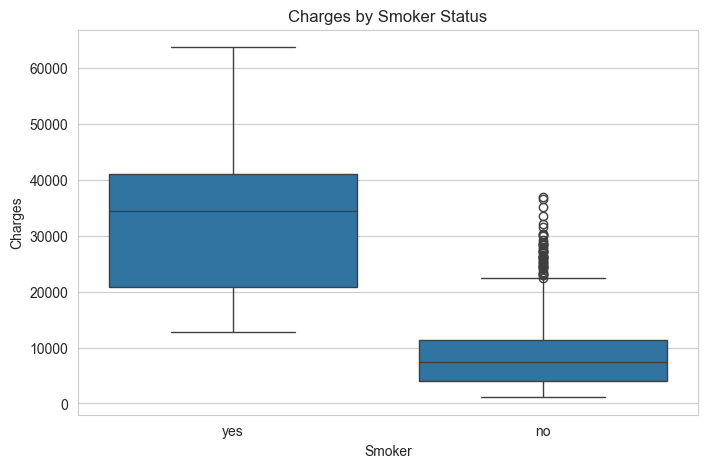

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=insurance_df, x="smoker", y="charges")
plt.title("Charges by Smoker Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

#### 5.6 Age, BMI, and charges

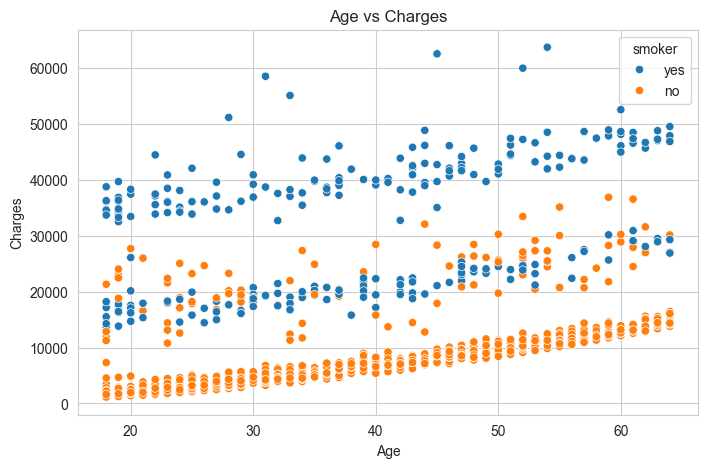

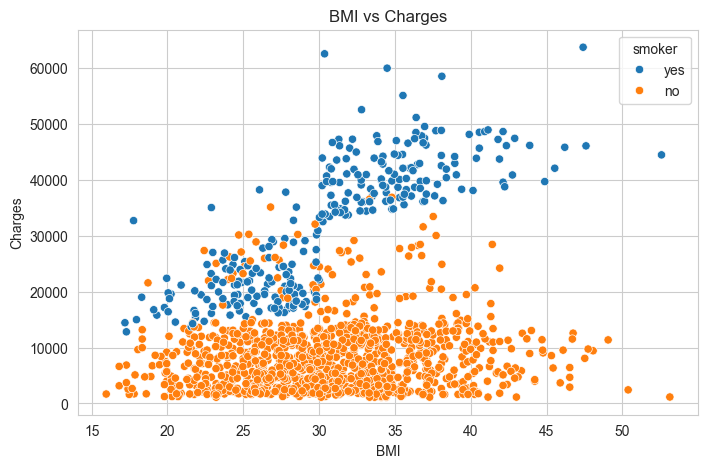

In [33]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=insurance_df, x="age", y="charges", hue="smoker")
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=insurance_df, x="bmi", y="charges", hue="smoker")
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

### 6. Diagnostic Analysis - Why is it happening?

#### 6.1 Correlation heatmap

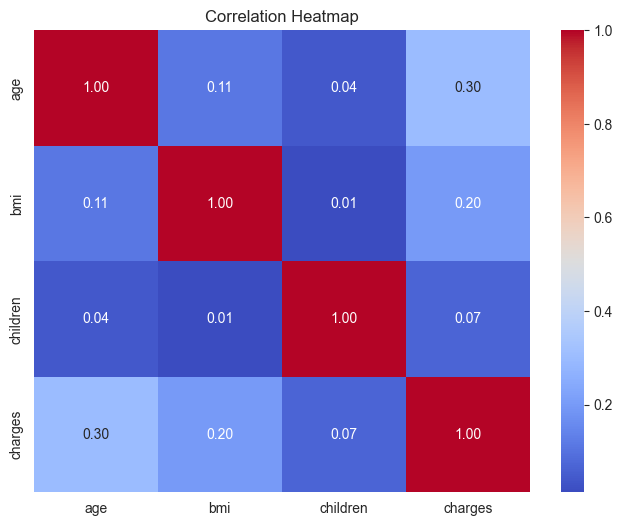

In [36]:
numeric_df = insurance_df[numerical_features + ["charges"]]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#### 6.2 Interaction: smoker + BMI

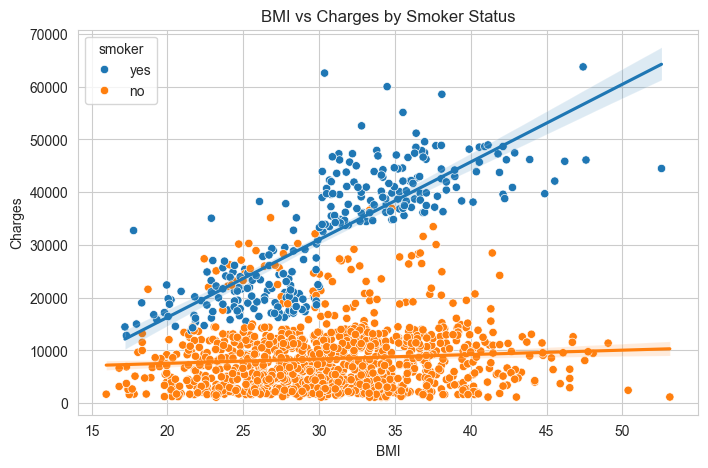

In [38]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=insurance_df, x="bmi", y="charges", hue="smoker")
sns.regplot(data=insurance_df[insurance_df["smoker"] == "yes"], x="bmi", y="charges", scatter=False)
sns.regplot(data=insurance_df[insurance_df["smoker"] == "no"], x="bmi", y="charges", scatter=False)
plt.title("BMI vs Charges by Smoker Status")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

#### 6.3 Charges by age groups

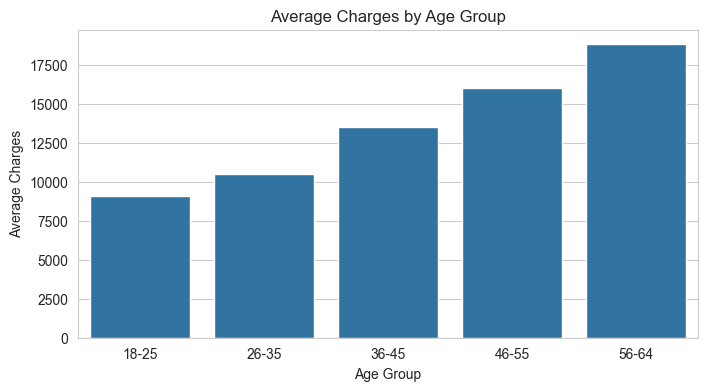

,avg_charges
age_group,
18-25,9087.015807
26-35,10495.163047
36-45,13493.485247
46-55,15986.900310
56-64,18795.993816


In [40]:
insurance_df["age_group"] = pd.cut(
    insurance_df["age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-64"]
)

avg_age_group = insurance_df.groupby("age_group")["charges"].mean()

plt.figure(figsize=(8, 4))
sns.barplot(x=avg_age_group.index, y=avg_age_group.values)
plt.title("Average Charges by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Charges")
plt.show()

display(avg_age_group.to_frame(name="avg_charges"))

#### 6.4 Charges by BMI categories

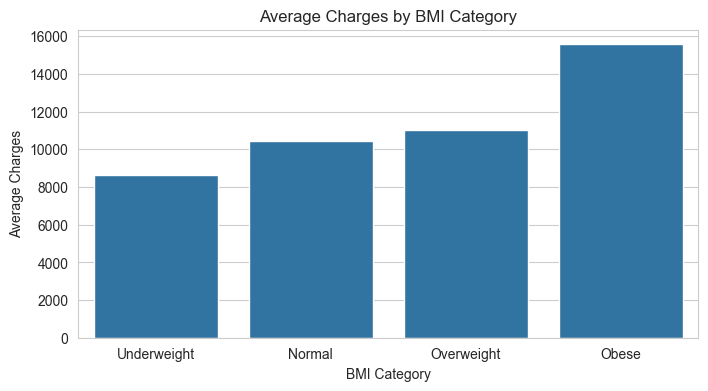

,avg_charges
bmi_category,
Underweight,8657.620652
Normal,10435.440719
Overweight,10997.803881
Obese,15560.926321


In [42]:
insurance_df["bmi_category"] = pd.cut(
    insurance_df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

avg_bmi_group = insurance_df.groupby("bmi_category")["charges"].mean()

plt.figure(figsize=(8, 4))
sns.barplot(x=avg_bmi_group.index, y=avg_bmi_group.values)
plt.title("Average Charges by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Average Charges")
plt.show()

display(avg_bmi_group.to_frame(name="avg_charges"))

#### 6.5 Smoker impact summary

In [44]:
smoker_summary = insurance_df.groupby("smoker")["charges"].agg(["mean", "median", "min", "max", "std", "count"])
display(smoker_summary)

smoker_diff = (
    insurance_df.groupby("smoker")["charges"].mean()["yes"]
    - insurance_df.groupby("smoker")["charges"].mean()["no"]
)

print(f"Difference in average charges between smokers and non-smokers: {smoker_diff:,.2f}")

,mean,median,min,max,std,count
smoker,,,,,,
no,8434.268298,7345.40530,1121.8739,36910.60803,5993.781819,1064
yes,32050.231832,34456.34845,12829.4551,63770.42801,11541.547176,274


Difference in average charges between smokers and non-smokers: 23,615.96
